0630: three sets of experiments
1. multi_0630: multi-objective, level=1: lipinski, level >1: docking, Milo FDA ngram
2. ngram_0630: multi-objectice, level=1: lipinski, level >1: docking, db ngram (re research diary 0620)
3. rev_0630: multi-objective, level < initial level: docking, outest level: lipinski, Milo FDA ngram

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.lines as mlines
import os
import matplotlib.patches as mpatches
import sys

parent_dir = "/Users/yalilyu/Desktop/result/"
sys.path.append(parent_dir)

from utils.lipinskiness import lipinskiness


In [2]:
single_toadd = {}
single = {}

for protein in ['ar','her2']:
    for n in [3,4]:
        for i in [1,2]:
            key = f"{protein}_l{n}_r{i}"
            file_path = f"../0623_result/old_ngram/{protein}_l{n}_r{i}.csv"
            
            if os.path.exists(file_path):
                print(file_path)
                single_toadd[key] = pd.read_csv(file_path, sep="\s+", header=None)
                single_toadd[key].columns = ["time","smiles", "lip_sc", "docking_sc"]
                single_toadd[key].index = range(1, len(single_toadd[key]) +1)
            else:
                continue

for protein in ['ar', 'her2']:
    for n in [3, 4]:
        key = f"{protein}_l{n}"
        key1 = f"{protein}_l{n}_r1"
        key2 = f"{protein}_l{n}_r2"
        if key1 in single_toadd and key2 in single_toadd:
            single[key] = pd.concat([single_toadd[key1], single_toadd[key2]], axis=0)
        elif key1 in single_toadd:
            single[key] = single_toadd[key1]
        elif key2 in single_toadd:
            single[key] = single_toadd[key2]
        else:
            print(f"Neither {key1} nor {key2} found.")

../0623_result/old_ngram/ar_l3_r1.csv
../0623_result/old_ngram/ar_l3_r2.csv
../0623_result/old_ngram/ar_l4_r1.csv
../0623_result/old_ngram/ar_l4_r2.csv
../0623_result/old_ngram/her2_l3_r1.csv
../0623_result/old_ngram/her2_l3_r2.csv
../0623_result/old_ngram/her2_l4_r1.csv
../0623_result/old_ngram/her2_l4_r2.csv


In [3]:
for key, df in single.items():
    single[key] = df[(df['lip_sc'] != -2.0) & (df['docking_sc']!= 1000.0)]

In [4]:
for level, df in single.items():
    num_mol = len(df)
    print(f"Number of molecules generated by single-objective {level} is {num_mol}")

Number of molecules generated by single-objective ar_l3 is 252
Number of molecules generated by single-objective ar_l4 is 3085
Number of molecules generated by single-objective her2_l3 is 124
Number of molecules generated by single-objective her2_l4 is 1041


In [5]:
multi_toadd = {}
multi = {}

for protein in ['ar', 'her2']:
    for i in [1, 2]:
        key = f"{protein}_l4_r{i}"
        file_path = f"multi_0630/{protein}_l4_r{i}.csv"
        if os.path.exists(file_path):
            print(file_path)
            multi_toadd[key] = pd.read_csv(file_path, sep="\s+", header=None)
            multi_toadd[key].columns = ["time", "smiles", "lip_sc", "docking_sc"]
            multi_toadd[key].index = range(1, len(multi_toadd[key]) + 1)

# Concatenate keys starting with 'ar' and 'her2' separately
for protein in ['ar', 'her2']:
    keys = [f"{protein}_l4_r{i}" for i in [1, 2]]
    dfs = [multi_toadd[key] for key in keys if key in multi_toadd]
    if dfs:
        multi[f"{protein}_l4"] = pd.concat(dfs, ignore_index=True)
    else:
        print(f"None of the files for {protein} found.")

multi_0630/ar_l4_r1.csv
multi_0630/ar_l4_r2.csv
multi_0630/her2_l4_r1.csv
multi_0630/her2_l4_r2.csv


In [6]:
for key, df in multi.items():
    multi[key] = df[(df['lip_sc'] != -2.0) & (df['docking_sc']!= 1000.0)]

In [7]:
for level, df in multi.items():
    num_mol = len(df)
    print(f"Number of molecules generated by multi-objective {level} is {num_mol}")

Number of molecules generated by multi-objective ar_l4 is 1256
Number of molecules generated by multi-objective her2_l4 is 1185


In [8]:
rev_toadd = {}
rev = {}

for protein in ['ar','her2']:
    for n in [3,4]:
        for i in [1,2]:
            key = f"{protein}_l{n}_r{i}"
            file_path = f"../result_0707/oldngram/CN_{protein}_l{n}_r{i}.csv"
            
            if os.path.exists(file_path):
                print(file_path)
                rev_toadd[key] = pd.read_csv(file_path, sep="\s+", header=None)
                rev_toadd[key].columns = ["time","smiles", "lip_sc", "docking_sc"]
                rev_toadd[key].index = range(1, len(rev_toadd[key]) +1)
            else:
                continue

for protein in ['ar', 'her2']:
    for n in [3, 4]:
        key = f"{protein}_l{n}"
        key1 = f"{protein}_l{n}_r1"
        key2 = f"{protein}_l{n}_r2"
        if key1 in rev_toadd and key2 in rev_toadd:
            rev[key] = pd.concat([rev_toadd[key1], rev_toadd[key2]], axis=0)
        elif key1 in rev_toadd:
            print(f"{key2} not found")
            rev[key] = rev_toadd[key1]
        elif key2 in rev_toadd:
            print(f"{key1} not found")
            rev[key] = rev_toadd[key2]
        else:
            print(f"Neither {key1} nor {key2} found.")

../result_0707/oldngram/CN_ar_l4_r1.csv
../result_0707/oldngram/CN_ar_l4_r2.csv
../result_0707/oldngram/CN_her2_l4_r1.csv
../result_0707/oldngram/CN_her2_l4_r2.csv
Neither ar_l3_r1 nor ar_l3_r2 found.
Neither her2_l3_r1 nor her2_l3_r2 found.


In [9]:
for key, df in rev.items():
    rev[key] = df[(df['lip_sc'] != -2.0) & (df['docking_sc']!= 1000.0)]

In [10]:
for level, df in rev.items():
    num_mol = len(df)
    print(f"Number of molecules generated by reversed multi-objective {level} is {num_mol}")

Number of molecules generated by reversed multi-objective ar_l4 is 1046
Number of molecules generated by reversed multi-objective her2_l4 is 1351


In [11]:
for key in ['ar_l4','her2_l4']:
    # Sample 1000 random rows without replacement
    sample_of_rev = rev[key].sample(n=1000, random_state=28).reset_index(drop=True)
    sample_df_single = single[key].sample(n=1000, random_state=28).reset_index(drop=True)
    
    # Assign back to the original dictionaries
    rev[key] = sample_of_rev
    single[key] = sample_df_single

In [12]:
multi_ave_lip_sc = []
multi_max_lip_sc = []
multi_ave_dock_sc = []
multi_min_dock_sc = []

multi_ci_lower_lip = []
multi_ci_upper_lip = []

multi_ci_lower_dock = []
multi_ci_upper_dock = []

for key, df in multi.items():
    multi_lip_sc_values = df['lip_sc'].values
    multi_docking_sc_values = df['docking_sc'].values
    
    multi_ave_lip = np.mean(multi_lip_sc_values)
    multi_q_lower_lip = np.percentile(multi_lip_sc_values, 2.5)
    multi_q_upper_lip = np.percentile(multi_lip_sc_values, 97.5)
    

    multi_ave_lip_sc.append(multi_ave_lip)
    multi_ci_lower_lip.append(multi_q_lower_lip)
    multi_ci_upper_lip.append(multi_q_upper_lip)
    

    multi_max_lip_sc.append(np.max(multi_lip_sc_values))
    

    multi_ave_dock = np.mean(multi_docking_sc_values)
    multi_q_lower_dock = np.percentile(multi_docking_sc_values, 2.5)
    multi_q_upper_dock = np.percentile(multi_docking_sc_values, 97.5)
    
    multi_ave_dock_sc.append(multi_ave_dock)
    multi_min_dock_sc.append(np.min(multi_docking_sc_values))
    multi_ci_lower_dock.append(multi_q_lower_dock)
    multi_ci_upper_dock.append(multi_q_upper_dock)


In [13]:
rev_ave_lip_sc = []
rev_max_lip_sc = []
rev_ave_dock_sc = []
rev_min_dock_sc = []

rev_ci_lower_lip = []
rev_ci_upper_lip = []

rev_ci_lower_dock = []
rev_ci_upper_dock = []

for key, df in rev.items():
    rev_lip_sc_values = df['lip_sc'].values
    rev_docking_sc_values = df['docking_sc'].values
    
    rev_ave_lip = np.mean(rev_lip_sc_values)
    rev_q_lower_lip = np.percentile(rev_lip_sc_values, 2.5)
    rev_q_upper_lip = np.percentile(rev_lip_sc_values, 97.5)
    

    rev_ave_lip_sc.append(rev_ave_lip)
    rev_ci_lower_lip.append(rev_q_lower_lip)
    rev_ci_upper_lip.append(rev_q_upper_lip)
    

    rev_max_lip_sc.append(np.max(rev_lip_sc_values))
    

    rev_ave_dock = np.mean(rev_docking_sc_values)
    rev_q_lower_dock = np.percentile(rev_docking_sc_values, 2.5)
    rev_q_upper_dock = np.percentile(rev_docking_sc_values, 97.5)
    
    rev_ave_dock_sc.append(rev_ave_dock)
    rev_min_dock_sc.append(np.min(rev_docking_sc_values))
    rev_ci_lower_dock.append(rev_q_lower_dock)
    rev_ci_upper_dock.append(rev_q_upper_dock)


In [14]:
ar_l4_top5 = rev['ar_l4'].sort_values(by='docking_sc',ascending=True).head(5)

In [15]:
list(ar_l4_top5['smiles'])

['C(C(C(F)C=C(C)(CO))C(F)(F)(F))1S(NN=C(O1)NC(F)(F)(F))',
 'C(F)(O)NC(N)C1=N(C(=O)NC(C1)C2=C(C(O)=CC=C2)(C(F)(F)(F)))',
 'C(F)(O)NC(N)C1=N(C(=O)NC(C1)C2=C(C(=O)NN2)C(F)(F)(F))',
 'C(CNS(CC1=C(C=CC=C1C(F)(F)(F))(C(F)(F)(F))))C(F)(F)(F)',
 'C(CNS(CC1=C(C=CC=C1C(F)(F)(F))C(F)(F)(F)))C(F)(F)(F)']

In [16]:
ar_smiles = rev['ar_l4']['smiles'].to_list()

dict_values([2.0, 2.0, 2.0])


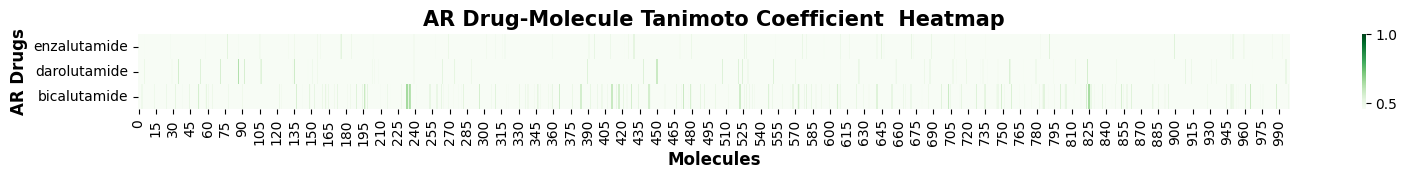

Highest tanimoto similarity score: 0.654


In [17]:
from rdkit import DataStructs
from rdkit.Chem import MACCSkeys
from rdkit.Chem import Draw
from rdkit import Chem
from rdkit.Chem.rdmolfiles import MolToSmarts, MolFromSmiles, MolFromSmarts

ar_drug_name = ['enzalutamide', 'darolutamide', 'bicalutamide']

ar_drug_smile = {'enzalutamide':'CC1(C(=O)N(C(=S)N1C2=CC(=C(C=C2)C(=O)NC)F)C3=CC(=C(C=C3)C#N)C(F)(F)F)C', 
               'darolutamide': 'CC(CN1C=CC(=N1)C2=CC(=C(C=C2)C#N)Cl)NC(=O)C3=NNC(=C3)C(C)O', 
               'bicalutamide': 'CC(CS(=O)(=O)C1=CC=C(C=C1)F)(C(=O)NC2=CC(=C(C=C2)C#N)C(F)(F)F)O'}

ar_drug_dock = {'enzalutamide': -6.8, 
               'darolutamide': -8.5, 
               'bicalutamide': -9.8}

ar_drug_lip = {}
for key, value in ar_drug_smile.items():
    lip_sc = lipinskiness(value)
    ar_drug_lip[key] = lip_sc
print(ar_drug_lip.values())

ar_drugs = [Chem.MolFromSmiles(drug) for drug in ar_drug_smile.values()]
ar_drug_fps = [ MACCSkeys.GenMACCSKeys(x) for x in ar_drugs]
ar_mols = [Chem.MolFromSmiles(smile) for smile in ar_smiles]
ar_mol_fps = [ MACCSkeys.GenMACCSKeys(x) for x in ar_mols]

similarity_matrix = np.zeros((len(ar_drugs), len(ar_mols)))



# Calculate similarity scores
for i in range(len(ar_drugs)):
    for j in range(len(ar_mols)):
        score = DataStructs.TanimotoSimilarity(ar_drug_fps[i], ar_mol_fps[j])
        similarity_matrix[i, j] = score
# Create a heatmap using seaborn
plt.figure(figsize=(16, 1))
sns.heatmap(similarity_matrix, annot=False, fmt=".2f", cmap='Greens', vmin=0.457, vmax=1,
            yticklabels=[f'{list(ar_drug_smile.keys())[i]}' for i in range(len(ar_drug_smile))])

plt.xlabel('Molecules', fontsize=12, fontweight='bold')
plt.ylabel('AR Drugs', fontsize=12, fontweight='bold')
plt.title('AR Drug-Molecule Tanimoto Coefficient  Heatmap', fontsize=15, fontweight='bold')
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.2, wspace=0.3, hspace=0.15)
plt.show()
max_score = np.max(similarity_matrix)
print(f"Highest tanimoto similarity score: {max_score:.3f}")


In [18]:
ar_tani_score = []
for i in range(len(ar_mols)):
    score = 0
    for j in range(len(ar_drugs)):
        tani_score = DataStructs.TanimotoSimilarity(ar_drug_fps[j], ar_mol_fps[i])
        if tani_score > score:
            score = tani_score
    ar_tani_score.append(score)
ar_tani_score = np.array(ar_tani_score)
print(f"Average Tanimoto score for AR-targeting molecules: {ar_tani_score.mean()}, \nstd: {ar_tani_score.std():.3f}")

Average Tanimoto score for AR-targeting molecules: 0.40813719609374616, 
std: 0.093


In [19]:
her2_smiles = rev['her2_l4'].smiles.to_list()

dict_values([2.0, 2.0, 1.8])
Highest tanimoto similarity score: 0.717


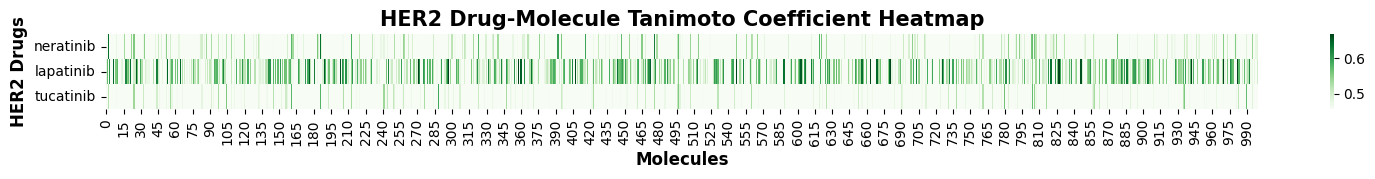

Average Tanimoto score for HER2-targeting molecules: 0.49355398049640387, 
std: 0.089


In [20]:
her2_drug_dir = {'neratinib':'CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=CC(=C(C=C3)OCC4=CC=CC=N4)Cl)C#N)NC(=O)C=CCN(C)C', 
               'lapatinib': 'CS(=O)(=O)CCNCC1=CC=C(O1)C2=CC3=C(C=C2)N=CN=C3NC4=CC(=C(C=C4)OCC5=CC(=CC=C5)F)Cl', 
               'tucatinib': 'CC1=C(C=CC(=C1)NC2=NC=NC3=C2C=C(C=C3)NC4=NC(CO4)(C)C)OC5=CC6=NC=NN6C=C5'}

her2_drug_dock = {'neratinib': -8.5, 
               'lapatinib': -9.7, 
               'tucatinib': -10.6}


her2_drug_lip = {}
for key, values in her2_drug_dir.items():
    lip_sc = lipinskiness(values)
    her2_drug_lip[key] = lip_sc
print(her2_drug_lip.values())


her2_drugs = [Chem.MolFromSmiles(drug) for drug in her2_drug_dir.values()]
her2_drug_fps = [ MACCSkeys.GenMACCSKeys(x) for x in her2_drugs]
her2_mols = [Chem.MolFromSmiles(smile) for smile in her2_smiles]
her2_mol_fps = [ MACCSkeys.GenMACCSKeys(x) for x in her2_mols]

similarity_matrix = np.zeros((len(her2_drugs), len(her2_mols)))

# Calculate similarity scores
for i in range(len(her2_drugs)):
    for j in range(len(her2_mols)):
        score = DataStructs.TanimotoSimilarity(her2_drug_fps[i], her2_mol_fps[j])
        similarity_matrix[i, j] = score
max_score = np.max(similarity_matrix)
print(f"Highest tanimoto similarity score: {max_score:.3f}")

# Create a heatmap using seaborn
plt.figure(figsize=(16, 1))
sns.heatmap(similarity_matrix, annot=False, fmt=".2f", cmap='Greens', vmin=0.457, vmax=0.667,
            yticklabels=[f'{list(her2_drug_dir.keys())[i]}' for i in range(len(her2_drug_dir))])

plt.xlabel('Molecules', fontsize=12, fontweight='bold')
plt.ylabel('HER2 Drugs', fontsize=12, fontweight='bold')
plt.title('HER2 Drug-Molecule Tanimoto Coefficient Heatmap', fontsize=15, fontweight='bold')
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.2, wspace=0.3, hspace=0.15)
plt.show()

her2_tani_score = []
for i in range(len(her2_mols)):
    score = 0
    for j in range(len(her2_drugs)):
        tani_score = DataStructs.TanimotoSimilarity(her2_drug_fps[j], her2_mol_fps[i])
        if tani_score > score:
            score = tani_score
    her2_tani_score.append(score)
her2_tani_score = np.array(her2_tani_score)
print(f"Average Tanimoto score for HER2-targeting molecules: {her2_tani_score.mean()}, \nstd: {her2_tani_score.std():.3f}")

In [21]:
single_ave_lip_sc = []
single_max_lip_sc = []
single_ave_dock_sc = []
single_min_dock_sc = []

single_ci_lower_lip = []
single_ci_upper_lip = []

single_ci_lower_dock = []
single_ci_upper_dock = []

for key, df in single.items():
    single_lip_sc_values = df['lip_sc'].values
    single_docking_sc_values = df['docking_sc'].values
    
    single_ave_lip = np.mean(single_lip_sc_values)
    single_q_lower_lip = np.percentile(single_lip_sc_values, 2.5)
    single_q_upper_lip = np.percentile(single_lip_sc_values, 97.5)
    

    single_ave_lip_sc.append(single_ave_lip)
    single_ci_lower_lip.append(single_q_lower_lip)
    single_ci_upper_lip.append(single_q_upper_lip)
    

    single_max_lip_sc.append(np.max(single_lip_sc_values))
    

    single_ave_dock = np.mean(single_docking_sc_values)
    single_q_lower_dock = np.percentile(single_docking_sc_values, 2.5)
    single_q_upper_dock = np.percentile(single_docking_sc_values, 97.5)
    
    single_ave_dock_sc.append(single_ave_dock)
    single_min_dock_sc.append(np.min(single_docking_sc_values))
    single_ci_lower_dock.append(single_q_lower_dock)
    single_ci_upper_dock.append(single_q_upper_dock)


In [22]:
# keys = ['ar_l3', 'ar_l4']
# n_plots = len(keys)

# # Create figure and axes
# fig, axs = plt.subplots(2, 2, figsize=(20, 10))
# axs = axs.flatten()

# # Compute y-limits for the top row (Lipinski scores)
# top_ylim_min = min(
#     min(multi_ci_lower_lip), min(rev_ci_lower_lip), min(single_ci_lower_lip)
# ) - 0.05

# top_ylim_max = max(
#     max(multi_ci_upper_lip), max(rev_ci_upper_lip), max(single_ci_upper_lip)
# ) +0.05

# # Compute y-limits for the bottom row (Docking scores)
# bottom_ylim_min = min(
#     min(multi_ci_lower_dock), min(rev_ci_lower_dock),  min(single_ci_lower_dock)
# ) -0.2
# bottom_ylim_max = max(
#     max(multi_ci_upper_dock), max(rev_ci_upper_dock), max(single_ci_upper_dock)
# ) + 0.2


# # Plot top row (first 2 plots)
# for i, key in enumerate(keys):
#     ax = axs[i]
#     multi_dock_mean = multi_ave_dock_sc[i]
#     multi_dock_lower = multi_ci_lower_dock[i]
#     multi_dock_upper = multi_ci_upper_dock[i]
#     multi_dock_err = [[multi_dock_mean - multi_dock_lower], [multi_dock_upper - multi_dock_mean]]
#     ax.errorbar(
#         0, multi_dock_mean,
#         yerr=multi_dock_err,
#         fmt='o',
#         capsize=4,
#         capthick=1.2
#     )
#     interval_str = f"[{multi_dock_lower:.2f}, {multi_dock_upper:.2f}]"
#     ax.text(-0.2, multi_dock_mean - 0.2, interval_str, fontsize=12, va='top', ha='left')

#     # Plot new
#     rev_dock_mean = rev_ave_dock_sc[i]
#     rev_dock_lower = rev_ci_lower_dock[i]
#     rev_dock_upper = rev_ci_upper_dock[i]
#     # Plot errorbar
#     rev_dock_err = [[rev_dock_mean - rev_dock_lower], [rev_dock_upper - rev_dock_mean]]
#     ax.errorbar(
#         1, rev_dock_mean,
#         yerr=rev_dock_err,
#         fmt='o',
#         capsize=4,
#         capthick=1.2
#     )
#     interval_str = f"[{rev_dock_lower:.2f}, {rev_dock_upper:.2f}]"
#     ax.text(0.8, rev_dock_mean - 0.2, interval_str, fontsize=12, va='top', ha='left')

#     # Plot single
#     single_dock_mean = single_ave_dock_sc[i]
#     single_dock_lower = single_ci_lower_dock[i]
#     single_dock_upper = single_ci_upper_dock[i]
#     # Plot errorbar
#     single_dock_err = [[single_dock_mean - single_dock_lower], [single_dock_upper - single_dock_mean]]
#     ax.errorbar(
#         2, single_dock_mean,
#         yerr=single_dock_err,
#         fmt='o',
#         capsize=4,
#         capthick=1.2
#     )
#     interval_str = f"[{single_dock_lower:.2f}, {single_dock_upper:.2f}]"
#     ax.text(1.8, single_dock_mean - 0.2, interval_str, fontsize=12, va='top', ha='left')


#     ax.set_xlim(-0.5, 2.5)
#     ax.set_xticks([0, 1 ,2])
#     ax.set_xticklabels(['multi', 'rev', 'single'])
#     ax.grid(False, axis='x')
#     if i == 0:
#         ax.set_ylabel('Docking Score',fontsize=15, fontweight='bold')
#     else:
#         ax.set_ylabel('')
#         ax.yaxis.set_visible(True)
#         # Set same y-limits for top row
#         ax.set_ylim(top_ylim_min, top_ylim_max)
#     # Set same y-limits for bottom row
#     ax.set_ylim(bottom_ylim_min, bottom_ylim_max)
#     ax = axs[i]


# # Plot bottom row (last 2 plots)
# for i, key in enumerate(keys):
#     ax = axs[i + 2]

#     multi_lip_mean = multi_ave_lip_sc[i]
#     multi_lip_lower = multi_ci_lower_lip[i]
#     multi_lip_upper = multi_ci_upper_lip[i]
#     # Plot errorbar
#     multi_lip_err = [[multi_lip_mean - multi_lip_lower], [multi_lip_upper - multi_lip_mean]]
#     ax.errorbar(
#         0, multi_lip_mean,
#         yerr=multi_lip_err,
#         fmt='o',
#         capsize=4,
#         capthick=1.2
#     )
#     interval_str = f"[{multi_lip_lower:.2f}, {multi_lip_upper:.2f}]"
#     ax.text(-0.2, multi_lip_mean - 0.05, interval_str, fontsize=12, va='top', ha='left')

#     # Plot new
#     rev_lip_mean = rev_ave_lip_sc[i]
#     rev_lip_lower = rev_ci_lower_lip[i]
#     rev_lip_upper = rev_ci_upper_lip[i]
#     # Plot errorbar
#     rev_lip_err = [[rev_lip_mean - rev_lip_lower], [rev_lip_upper - rev_lip_mean]]
#     ax.errorbar(
#         1, rev_lip_mean,
#         yerr=rev_lip_err,
#         fmt='o',
#         capsize=4,
#         capthick=1.2
#     )
#     interval_str = f"[{rev_lip_lower:.2f}, {rev_lip_upper:.2f}]"
#     ax.text(0.8, rev_lip_mean - 0.05, interval_str, fontsize=12, va='top', ha='left')
#     ax.set_xlim(-0.5, 1.5)
#     ax.set_xticks([0, 1, 2])
#     ax.set_xticklabels(['multi', 'rev', 'single'])
#     ax.grid(False, axis='x')

#     # Plot single
#     single_lip_mean = single_ave_lip_sc[i]
#     single_lip_lower = single_ci_lower_lip[i]
#     single_lip_upper = single_ci_upper_lip[i]
#     # Plot errorbar
#     single_lip_err = [[single_lip_mean - single_lip_lower], [single_lip_upper - single_lip_mean]]
#     ax.errorbar(
#         2, single_lip_mean,
#         yerr=single_lip_err,
#         fmt='o',
#         capsize=4,
#         capthick=1.2
#     )
#     interval_str = f"[{single_lip_lower:.2f}, {single_lip_upper:.2f}]"
#     ax.text(1.8, single_lip_mean - 0.05, interval_str, fontsize=12, va='top', ha='left')


#     ax.set_xlim(-0.5, 2.5)
#     ax.set_xticks([0, 1, 2])
#     ax.set_xticklabels(['multi', 'rev', 'single'])
#     ax.grid(False, axis='x')


#     # ax.set_title(f'{key}')
#     if i == 0:
#         ax.set_ylabel('Lipinski Score', fontsize=15, fontweight='bold')
#     else:
#         ax.set_ylabel('')
#         ax.yaxis.set_visible(True)
#         # Set same y-limits for top row
#     ax.set_ylim(top_ylim_min, top_ylim_max)
#     ax.text(0.5, -0.15, f'{key}', ha='center', va='top', transform=ax.transAxes, fontsize=15, fontweight='bold')


# plt.suptitle("Docking / Lipinski Score with 95% CI, Multi Objective (multi vs rev) and Single", fontsize=20, fontweight='bold', y=1.02)
# plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.2, wspace=0.3, hspace=0.15)
# plt.show()

In [23]:
# keys = ['ar_l3', 'ar_l4']
# n_plots = len(keys)

# # Create figure and axes
# fig, axs = plt.subplots(2, 2, figsize=(16, 8))
# axs = axs.flatten()

# for i, key in enumerate(keys):
#     ax = axs[i+2]
    
#     # --- Plot for Lipinski scores (top row)
#     # Raw data for old and new
#     old_data_lip = multi[key]['lip_sc']
#     new_data_lip = rev[key]['lip_sc']
#     single_data_lip = single[key]['lip_sc']
#     lip_min = min(np.min([np.min(multi[key]['lip_sc']) for key in keys]),
#               np.min([np.min(rev[key]['lip_sc']) for key in keys]),
#               np.min([np.min(single[key]['lip_sc']) for key in keys])) -0.05
#     lip_max = max(np.max([np.max(multi[key]['lip_sc']) for key in keys]),
#               np.max([np.max(rev[key]['lip_sc']) for key in keys]),
#               np.max([np.max(single[key]['lip_sc']) for key in keys])) +0.05
    
#     # Plot violin for old Lipinski scores
#     parts = ax.violinplot([old_data_lip], positions=[0], showmeans=False, showmedians=True, showextrema=False)
#     # Optional: customize color, alpha
#     for pc in parts['bodies']:
#         pc.set_facecolor('blue')
#         pc.set_alpha(0.3)
    
#     # Plot violin for new Lipinski scores
#     parts = ax.violinplot([new_data_lip], positions=[1], showmeans=False, showmedians=True, showextrema=False)
#     for pc in parts['bodies']:
#         pc.set_facecolor('orange')
#         pc.set_alpha(0.3)
    
    
#     parts = ax.violinplot([single_data_lip], positions=[2], showmeans=False, showmedians=True, showextrema=False)
#     for pc in parts['bodies']:
#         pc.set_facecolor('red')
#         pc.set_alpha(0.3)

        
    
#     # Calculate and show median
#     median_old = np.median(old_data_lip)
#     median_new = np.median(new_data_lip)
#     median_single = np.median(single_data_lip)
#     ax.text(0, median_old, f"{median_old:.2f}", ha='center', va='bottom', fontsize=15, color='black',fontweight='bold')
#     ax.text(1, median_new, f"{median_new:.2f}", ha='center', va='bottom', fontsize=15, color='black',fontweight='bold')
#     ax.text(2, median_single, f"{median_single:.2f}", ha='center', va='bottom', fontsize=15, color='black',fontweight='bold')

#     ax.set_xlim(-0.5, 2.5)
#     ax.set_xticks([0, 1, 2])
#     ax.set_xticklabels(['multi', 'rev', 'single'], fontsize=15, fontweight='bold')
#     if i == 0:
#         ax.set_ylabel('Drug-like Score', fontsize=12, fontweight='bold')
#     else:
#         ax.set_ylabel('')
#         ax.yaxis.set_visible(True)
#     ax.grid(False, axis='x')
#     ax.set_ylim(lip_min, lip_max)
#     ax.text(0.5, -0.2, f'{key.upper()}', ha='center', va='top', transform=ax.transAxes, fontsize=20, fontweight='bold')

# # --- Plot for Docking scores (bottom row)
# for i, key in enumerate(keys):
#     ax = axs[i]
    
#     # Raw data for old and new
#     old_data_dock = multi[key]['docking_sc']
#     new_data_dock = rev[key]['docking_sc']
#     single_data_dock = single[key]['docking_sc']

#     dock_min = min(np.min([np.min(multi[key]['docking_sc']) for key in keys]),
#                np.min([np.min(single[key]['docking_sc']) for key in keys]),
#                np.min([np.min(rev[key]['docking_sc']) for key in keys])) - 0.1
#     # dock_max = max(np.max([np.max(multi[key]['docking_sc']) for key in keys]),
#     #            np.max([np.max(single[key]['docking_sc']) for key in keys]),
#     #            np.max([np.max(rev[key]['docking_sc']) for key in keys])) + 0.1
#     dock_max = 20
    
#     # Plot violin for old Docking scores
#     parts = ax.violinplot([old_data_dock], positions=[0], showmeans=False, showmedians=True, showextrema=False)
#     for pc in parts['bodies']:
#         pc.set_facecolor('blue')
#         pc.set_alpha(0.3)
#     # Plot violin for new Docking scores
#     parts = ax.violinplot([new_data_dock], positions=[1], showmeans=False, showmedians=True, showextrema=False)
#     for pc in parts['bodies']:
#         pc.set_facecolor('orange')
#         pc.set_alpha(0.3)
    
#     parts = ax.violinplot([single_data_dock], positions=[2], showmeans=False, showmedians=True, showextrema=False)
#     for pc in parts['bodies']:
#         pc.set_facecolor('red')
#         pc.set_alpha(0.3)

#     # Medians
#     median_old = np.median(old_data_dock)
#     median_new = np.median(new_data_dock)
#     median_single = np.median(single_data_dock)
#     ax.text(0, median_old, f"{median_old:.2f}", ha='center', va='bottom', fontsize=15, color='black',fontweight='bold')
#     ax.text(1, median_new, f"{median_new:.2f}", ha='center', va='bottom', fontsize=15, color='black',fontweight='bold')
#     ax.text(2, median_single, f"{median_single:.2f}", ha='center', va='bottom', fontsize=15, color='black',fontweight='bold')

#     ax.set_xlim(-0.5, 2.5)
#     ax.set_xticks([0, 1, 2])
#     ax.set_xticklabels(['multi', 'rev', 'single'], fontsize=12, fontweight='bold')
#     if i == 0:
#         ax.set_ylabel('Pseudo Free Energy of Binding (kcal/mol)', fontsize=12, fontweight='bold')
#     else:
#         ax.set_ylabel('')
#         ax.yaxis.set_visible(True)
#     ax.set_ylim(dock_min, dock_max)
#     ax.grid(False, axis='x')

# plt.suptitle("Violin Plots for Binding / Drug-like Scores: Multi-Objective (multi and rev) vs Single-Obejective", fontsize=20, fontweight='bold', y=1.0)
# plt.subplots_adjust(left=0.05, right=0.9, top=0.9, bottom=0.0, wspace=0.3, hspace=0.2)
# plt.show()

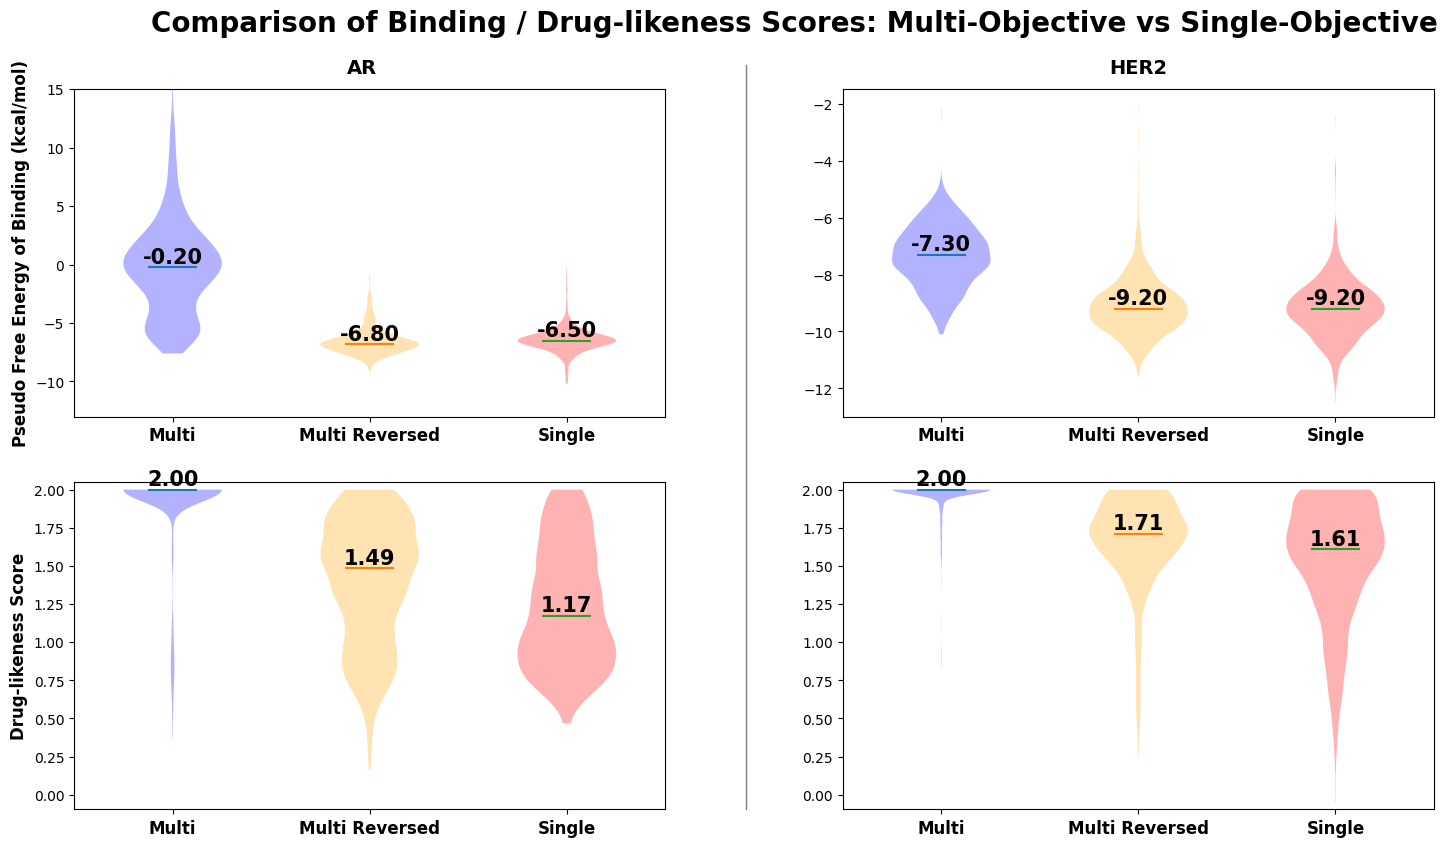

In [24]:
keys = ['ar_l4', 'her2_l4']
n_plots = len(keys)

# Create figure and axes
fig, axs = plt.subplots(2, 2, figsize=(16, 8))
axs = axs.flatten()

for i, key in enumerate(keys):
    ax = axs[i+2]
    
    # --- Plot for Lipinski scores (top row)
    # Raw data for old and new
    old_data_lip = multi[key]['lip_sc']
    new_data_lip = rev[key]['lip_sc']
    single_data_lip = single[key]['lip_sc']
    lip_min = min(np.min([np.min(multi[k]['lip_sc']) for k in keys]),
                  np.min([np.min(rev[k]['lip_sc']) for k in keys]),
                  np.min([np.min(single[k]['lip_sc']) for k in keys])) - 0.05
    lip_max = max(np.max([np.max(multi[k]['lip_sc']) for k in keys]),
                  np.max([np.max(rev[k]['lip_sc']) for k in keys]),
                  np.max([np.max(single[k]['lip_sc']) for k in keys])) + 0.05
    
    # Plot violin for old Lipinski scores
    parts = ax.violinplot([old_data_lip], positions=[0], showmeans=False, showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor('blue')
        pc.set_alpha(0.3)
    
    # Plot violin for new Lipinski scores
    parts = ax.violinplot([new_data_lip], positions=[1], showmeans=False, showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor('orange')
        pc.set_alpha(0.3)
    
    # Plot violin for single Lipinski scores
    parts = ax.violinplot([single_data_lip], positions=[2], showmeans=False, showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor('red')
        pc.set_alpha(0.3)

    # Medians
    median_old = np.median(old_data_lip)
    median_new = np.median(new_data_lip)
    median_single = np.median(single_data_lip)
    ax.text(0, median_old, f"{median_old:.2f}", ha='center', va='bottom', fontsize=15, color='black', fontweight='bold')
    ax.text(1, median_new, f"{median_new:.2f}", ha='center', va='bottom', fontsize=15, color='black', fontweight='bold')
    ax.text(2, median_single, f"{median_single:.2f}", ha='center', va='bottom', fontsize=15, color='black', fontweight='bold')

    ax.set_xlim(-0.5, 2.5)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Multi', 'Multi Reversed', 'Single'], fontsize=12, fontweight='bold')
    if i == 0:
        ax.set_ylabel('Drug-likeness Score', fontsize=12, fontweight='bold')
    else:
        ax.set_ylabel('')
        ax.yaxis.set_visible(True)
    ax.grid(False, axis='x')
    ax.set_ylim(lip_min, lip_max)

# --- Plot for Docking scores (bottom row)
for i, key in enumerate(keys):
    ax = axs[i]
    
    # Raw data for old and new
    old_data_dock = multi[key]['docking_sc']
    new_data_dock = rev[key]['docking_sc']
    single_data_dock = single[key]['docking_sc']
    parts = ax.violinplot([old_data_dock], positions=[0], showmeans=False, showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor('blue')
        pc.set_alpha(0.3)
    # Plot violin for new Docking scores
    parts = ax.violinplot([new_data_dock], positions=[1], showmeans=False, showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor('orange')
        pc.set_alpha(0.3)
    # Plot violin for single Docking scores
    parts = ax.violinplot([single_data_dock], positions=[2], showmeans=False, showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor('red')
        pc.set_alpha(0.3)

    # Medians
    median_old = np.median(old_data_dock)
    median_new = np.median(new_data_dock)
    median_single = np.median(single_data_dock)
    ax.text(0, median_old, f"{median_old:.2f}", ha='center', va='bottom', fontsize=15, color='black', fontweight='bold')
    ax.text(1, median_new, f"{median_new:.2f}", ha='center', va='bottom', fontsize=15, color='black', fontweight='bold')
    ax.text(2, median_single, f"{median_single:.2f}", ha='center', va='bottom', fontsize=15, color='black', fontweight='bold')

    ax.set_xlim(-0.5, 2.5)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Multi', 'Multi Reversed', 'Single'], fontsize=12, fontweight='bold')
    if i == 0:
        ax.set_ylabel('Pseudo Free Energy of Binding (kcal/mol)', fontsize=12, fontweight='bold')
    else:
        ax.set_ylabel('')
        ax.yaxis.set_visible(True)
    axs[0].set_ylim(-13, 15)
    ax.grid(False, axis='x')
fig.text(0.23, 0.92, 'AR', ha='center', fontsize=14, fontweight='bold')
fig.text(0.715, 0.92, 'HER2', ha='center', fontsize=14, fontweight='bold')


plt.subplots_adjust(left=0.1, right=0.9, top=0.86, bottom=0.05, hspace=0.2)
import matplotlib.lines as mlines
line = mlines.Line2D([0.47, 0.47], [0.0, 0.93], transform=plt.gcf().transFigure,
                     color='grey', linewidth=1)
plt.gcf().add_artist(line)
plt.suptitle("Comparison of Binding / Drug-likeness Scores: Multi-Objective vs Single-Objective", fontsize=20, fontweight='bold', y=1.0)
plt.subplots_adjust(left=0.05, right=0.9, top=0.9, bottom=0.0, wspace=0.3, hspace=0.2)
plt.show()

In [25]:
import numpy as np
from scipy.stats import mannwhitneyu

# Example: For each subplot, calculate p-values between pairs
for i, key in enumerate(keys):
    # For Lipinski scores
    old_data_lip = multi[key]['lip_sc']
    new_data_lip = rev[key]['lip_sc']
    single_data_lip = single[key]['lip_sc']
    
    p_value_old_vs_new_lip = mannwhitneyu(old_data_lip, new_data_lip, alternative='two-sided').pvalue
    p_value_old_vs_single_lip = mannwhitneyu(old_data_lip, single_data_lip, alternative='two-sided').pvalue
    p_value_new_vs_single_lip = mannwhitneyu(new_data_lip, single_data_lip, alternative='two-sided').pvalue
    
    # For Docking scores
    old_data_dock = multi[key]['docking_sc']
    new_data_dock = rev[key]['docking_sc']
    single_data_dock = single[key]['docking_sc']
    
    p_value_old_vs_new_dock = mannwhitneyu(old_data_dock, new_data_dock, alternative='two-sided').pvalue
    p_value_old_vs_single_dock = mannwhitneyu(old_data_dock, single_data_dock, alternative='two-sided').pvalue
    p_value_new_vs_single_dock = mannwhitneyu(new_data_dock, single_data_dock, alternative='two-sided').pvalue
    
    # Example of printing or storing p-values
    print(f"Results for {key}:")
    print(f" Lipinski Old vs New: p={p_value_old_vs_new_lip:.3e}")
    print(f" Lipinski Old vs Single: p={p_value_old_vs_single_lip:.3e}")
    print(f" Lipinski New vs Single: p={p_value_new_vs_single_lip:.4e}")
    print(f" Docking Old vs New: p={p_value_old_vs_new_dock:.4e}")
    print(f" Docking Old vs Single: p={p_value_old_vs_single_dock:.4e}")
    print(f" Docking New vs Single: p={p_value_new_vs_single_dock:.4e}")


Results for ar_l4:
 Lipinski Old vs New: p=2.632e-265
 Lipinski Old vs Single: p=2.742e-289
 Lipinski New vs Single: p=4.7077e-19
 Docking Old vs New: p=1.7342e-293
 Docking Old vs Single: p=2.3398e-287
 Docking New vs Single: p=1.1030e-08
Results for her2_l4:
 Lipinski Old vs New: p=5.440e-268
 Lipinski Old vs Single: p=9.571e-282
 Lipinski New vs Single: p=1.4347e-12
 Docking Old vs New: p=1.8608e-221
 Docking Old vs Single: p=1.5401e-231
 Docking New vs Single: p=3.9857e-01


In [26]:

ar_docking_sc = []
all_single_lip_sc = []
all_rev_lip_sc = []
for key in ['ar_l3', 'ar_l4']:
    ar_docking_sc.extend(single[key]['docking_sc'])
    ar_docking_sc.extend(rev[key]['docking_sc'])
    all_single_lip_sc.extend(single[key]['lip_sc'])
    all_single_lip_sc.extend(rev[key]['lip_sc'])
ar_ymin, ar_ymax = min(ar_docking_sc), max(ar_docking_sc)

# Collect 'her2' datasets
her2_docking_sc = []
for key in ['her2_l3', 'her2_l4']:
    her2_docking_sc.extend(single[key]['docking_sc'])
    her2_docking_sc.extend(rev[key]['docking_sc'])
    all_single_lip_sc.extend(single[key]['lip_sc'])
    all_rev_lip_sc.extend(rev[key]['lip_sc'])
her2_ymin, her2_ymax = min(her2_docking_sc), max(her2_docking_sc)
x_min = min(min(all_single_lip_sc), min(all_rev_lip_sc))
x_max = max(max(all_single_lip_sc), max(all_rev_lip_sc))


fig, axs = plt.subplots(2, 4, figsize=(20, 10))
plot_keys_old = ['ar_l3', 'ar_l4', 'her2_l3', 'her2_l4']
plot_keys_new = ['ar_l3', 'ar_l4', 'her2_l3', 'her2_l4']
positions = [(0,0), (0,1), (0,2), (0,3),
             (1,0), (1,1), (1,2), (1,3)]


# Plot old datasets
color_ar = 'green'
color_her2 = 'brown'

# Plot old datasets
for i, key in enumerate(plot_keys_old):
    row, col = positions[i]
    color = color_ar if key.startswith('ar') else color_her2
    sns.scatterplot(
        x=single[key]['lip_sc'],
        y=single[key]['docking_sc'],
        ax=axs[row, col],
        color=color,  # use the color based on prefix
        alpha=0.8,
        label=f'{key} (single)',
        legend=False
    )
    axs[row, col].set_title(f'{key} (single)')
    # axs[row, col].set_ylabel('Docking Score')
    if key.startswith('ar'):
        axs[row, col].set_ylim(ar_ymin-0.1, ar_ymax+0.1)
    elif key.startswith('her2'):
        axs[row, col].set_ylim(her2_ymin-0.1, her2_ymax+0.1)
    axs[row, col].set_xlim(x_min-0.1, x_max+0.1)

# Similarly for new datasets
for j, key in enumerate(plot_keys_new):
    row, col = positions[j + 4]
    color = color_ar if key.startswith('ar') else color_her2
    sns.scatterplot(
        x=rev[key]['lip_sc'],
        y=rev[key]['docking_sc'],
        ax=axs[row, col],
        color=color,
        alpha=0.8,
        label=f'{key} (rev)',
        legend=False
    )
    axs[row, col].set_title(f'{key} (rev)')
    # axs[row, col].set_xlabel('Lipinski Score')
    # axs[row, col].set_ylabel('Docking Score')
    if key.startswith('ar'):
        axs[row, col].set_ylim(ar_ymin-0.1, ar_ymax+0.1)
    elif key.startswith('her2'):
        axs[row, col].set_ylim(her2_ymin-0.1, her2_ymax+0.1)
    axs[row, col].set_xlim(x_min-0.1, x_max+0.1)

for row in range(2):
    for col in range(4):
        ax = axs[row, col]
        if col != 0:
            ax.set_ylabel('')
        else:
            ax.set_ylabel('Docking Score')
        if row == 0:
            ax.set_xlabel('')
        else:
            ax.set_xlabel('Lipinski Score')

# Main title and layout
fig.suptitle('Docking score vs Lipinskiness score, single vs multi(rev) objective', fontsize=16, y=0.98, fontweight='bold')
fig.text(0.5, 0.91, 'single', ha='center', fontsize=14, fontweight='bold')
fig.text(0.5, 0.47, 'rev', ha='center', fontsize=14, fontweight='bold')
# line = mlines.Line2D([0.03, 0.97], [0.47, 0.47], transform=fig.transFigure, color='grey', linewidth=0.5)
# fig.add_artist(line)
plt.subplots_adjust(left=0.05, right=0.95, top=0.87, bottom=0.1, wspace=0.3, hspace=0.3)
plt.show()

KeyError: 'ar_l3'

In [27]:
ar_drug_pts = {drug: (ar_drug_lip[drug], ar_drug_dock[drug]) for drug in ar_drug_lip}

print(ar_drug_pts)

her2_drug_pts = {drug: (her2_drug_lip[drug], her2_drug_dock[drug]) for drug in her2_drug_lip}
print(her2_drug_pts)

{'enzalutamide': (2.0, -6.8), 'darolutamide': (2.0, -8.5), 'bicalutamide': (2.0, -9.8)}
{'neratinib': (2.0, -8.5), 'lapatinib': (2.0, -9.7), 'tucatinib': (1.8, -10.6)}


In [28]:
db_toadd = {}
db = {}

for protein in ['ar','her2']:
    for i in [1,2,3]:
        key = f"{protein}_l4_r{i}"
        file_path = f"../result_0707/newngram/{protein}_l4_r{i}.csv"
        
        if os.path.exists(file_path):
            print(file_path)
            db_toadd[key] = pd.read_csv(file_path, sep="\s+", header=None)
            db_toadd[key].columns = ["time","smiles", "lip_sc", "docking_sc"]
            db_toadd[key].index = range(1, len(db_toadd[key]) +1)
        else:
            continue

for protein in ['ar','her2']:
        key = f"{protein}_l4"
        key1 = f"{protein}_l4_r1"
        key2 = f"{protein}_l4_r2"
        key3 = f"{protein}_l4_r3"
        if key1 in db_toadd and key2 in db_toadd:
            db[key] = pd.concat([db_toadd[key1], db_toadd[key2], db_toadd[key3]], axis=0)
        elif key1 in db_toadd:
            db[key] = db_toadd[key1]
        elif key2 in db_toadd:
            db[key] = db_toadd[key2]
        elif key3 in db_toadd:
            db[key] = db_toadd[key3]
        else:
            print(f"Neither {key1} nor {key2} nor {key3} found.")

for key in ['ar_l4','her2_l4']:
    # Sample 1000 random rows without replacement
    sample_df_db = db[key].sample(n=1000, random_state=28).reset_index(drop=True)
    
    # Assign back to the original dictionaries
    db[key] = sample_df_db

../result_0707/newngram/ar_l4_r1.csv
../result_0707/newngram/ar_l4_r2.csv
../result_0707/newngram/ar_l4_r3.csv
../result_0707/newngram/her2_l4_r1.csv
../result_0707/newngram/her2_l4_r2.csv
../result_0707/newngram/her2_l4_r3.csv


/opt/anaconda3/envs/dsmc2/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/opt/anaconda3/envs/dsmc2/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/opt/anaconda3/envs/dsmc2/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/opt/anaconda3/envs/dsmc2/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


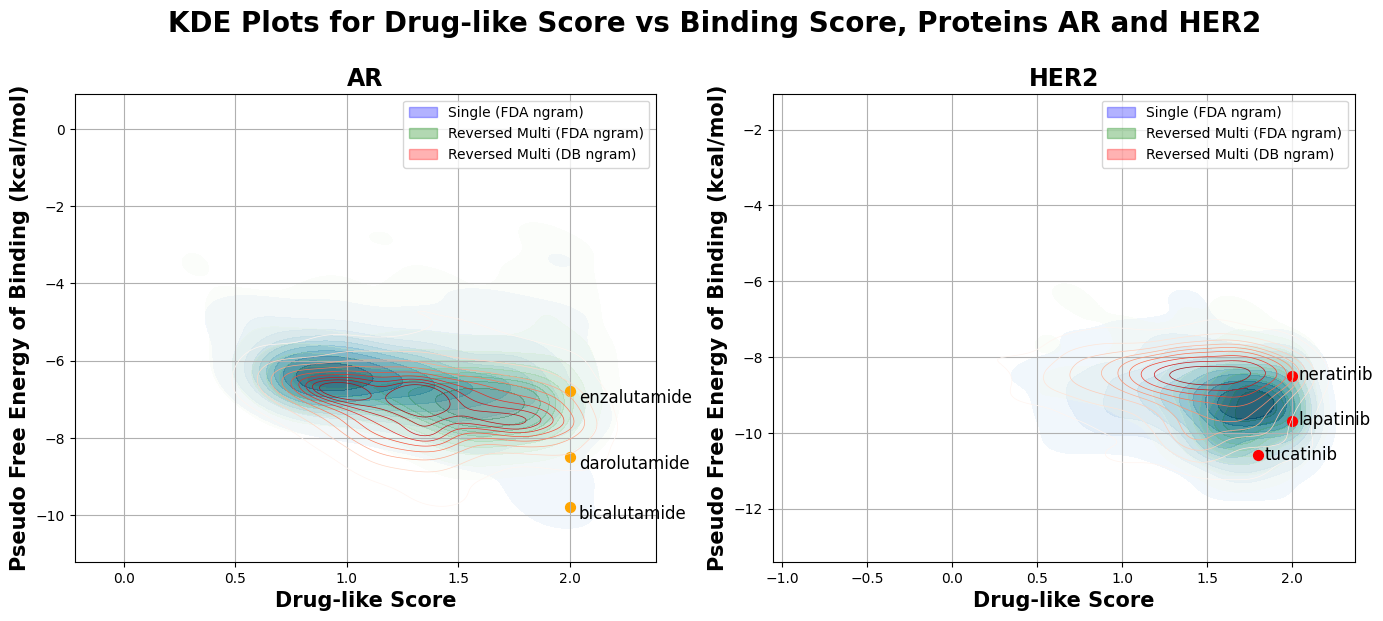

In [29]:
selected_keys = [ 'ar_l4', 'her2_l4']

# Create figure with 2x2 subplots
nrows, ncols = 1, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6))
axes = axes.flatten()



# Plot density for each key
for i, key in enumerate(selected_keys):
    ax = axes[i]
    if key in single and key in rev and key in db:
        # Data
        x_single = single[key]['lip_sc']
        y_single = single[key]['docking_sc']
        x_rev = rev[key]['lip_sc']
        y_rev = rev[key]['docking_sc']
        x_db = db[key]['lip_sc']
        y_db = db[key]['docking_sc']


        # Plot 'single' KDE fill
        sns.kdeplot(x=x_single, y=y_single, fill=True, levels=10, linewidths=0,
                    cmap='Blues', alpha = 0.8,ax=ax, label='Single')
        # Plot 'rev' KDE fill
        sns.kdeplot(x=x_rev, y=y_rev, fill=True, levels=10, linewidths=0,
                    cmap='Greens',ax=ax, alpha = 0.3,label='Reversed Multi')
        sns.kdeplot(x=x_db, y=y_db, fill=False, levels=10, linewidths=0.5,
                    cmap='Reds',alpha = 1,ax=ax, label='Reversed Multi (DB)')
        
        if key.startswith('ar'):
            for drug, (lip, dock) in ar_drug_pts.items():
                ax.scatter(lip,dock,label=drug, s=50, color='orange')
                ax.text(lip + 0.04, dock - 0.3, drug, fontsize=12)

    # Plot points for 'her2' if keys start with 'her2'
        elif key.startswith('her2'):
            for drug, (lip, dock) in her2_drug_pts.items():
                ax.scatter(lip,dock,label=drug, s=50, color='red')
                ax.text(lip + 0.04, dock - 0.1, drug, fontsize=12)

        # sns.scatterplot()
        axes[0].set_title('AR', fontsize=17, fontweight='bold')
        axes[1].set_title('HER2', fontsize=17, fontweight='bold')
        ax.set_xlabel('Drug-like Score',fontsize=15, fontweight='bold' )
        ax.set_ylabel('Pseudo Free Energy of Binding (kcal/mol)',fontsize=15, fontweight='bold')
        ax.grid(True)

        # Legends
        blue_patch = mpatches.Patch(color='blue', alpha = 0.3, label='Single (FDA ngram)')
        green_patch = mpatches.Patch(color='green', alpha = 0.3,label='Reversed Multi (FDA ngram)')
        red_patch = mpatches.Patch(color='red', alpha = 0.3,label='Reversed Multi (DB ngram)')

        ax.legend(handles=[blue_patch, green_patch, red_patch ], fontsize= 10)
    else:
        ax.set_visible(False)


# Collect axes for 'ar' and 'her2' groups
ar_axes = [ax for key, ax in zip(selected_keys, axes) if key.startswith('ar')]
her2_axes = [ax for key, ax in zip(selected_keys, axes) if key.startswith('her2')]
if ar_axes:
    ar_xlim = (
        min(ax.get_xlim()[0] for ax in ar_axes),
        max(ax.get_xlim()[1] for ax in ar_axes)
    )
    ar_ylim = (
        min(ax.get_ylim()[0] for ax in ar_axes),
        max(ax.get_ylim()[1] for ax in ar_axes)
    )
    


# Compute combined axes limits for 'her2' group
if her2_axes:
    her2_xlim = (
        min(ax.get_xlim()[0] for ax in her2_axes),
        max(ax.get_xlim()[1] for ax in her2_axes)
    )
    her2_ylim = (
        min(ax.get_ylim()[0] for ax in her2_axes),
        max(ax.get_ylim()[1] for ax in her2_axes)
    )
# Set same axes limits for 'ar' plots
if ar_axes:
    for ax in ar_axes:
        ax.set_xlim(*ar_xlim)
        ax.set_ylim(*ar_ylim)

# Set same axes limits for 'her2' plots
if her2_axes:
    for ax in her2_axes:
        ax.set_xlim(*her2_xlim)
        ax.set_ylim(*her2_ylim)

# Adjust layout
fig.suptitle('KDE Plots for Drug-like Score vs Binding Score, Proteins AR and HER2', fontsize=20, fontweight='bold',y=1.02)
plt.subplots_adjust(left=0.1, right=0.9, top=0.88, bottom=0.1, wspace=0.2, hspace=0.3)
plt.show()


In [30]:
multi_plot = {}
for i in range(1,11):
    multi_df = pd.read_csv(f'../result_0630/exmple_lineplot/ar_multi_{i}.csv', sep="\s+", header=None)
    multi_df.columns = ['time','smile','lipinski_sc','docking_sc']
    multi_plot[i] = multi_df

In [31]:
rev_plot = {}
for i in range(1,11):
    rev_df = pd.read_csv(f'../result_0630/exmple_lineplot/ar_rev_{i}.csv', sep="\s+", header=None)
    rev_df.columns = ['time','smile','lipinski_sc','docking_sc']
    rev_plot[i] = rev_df

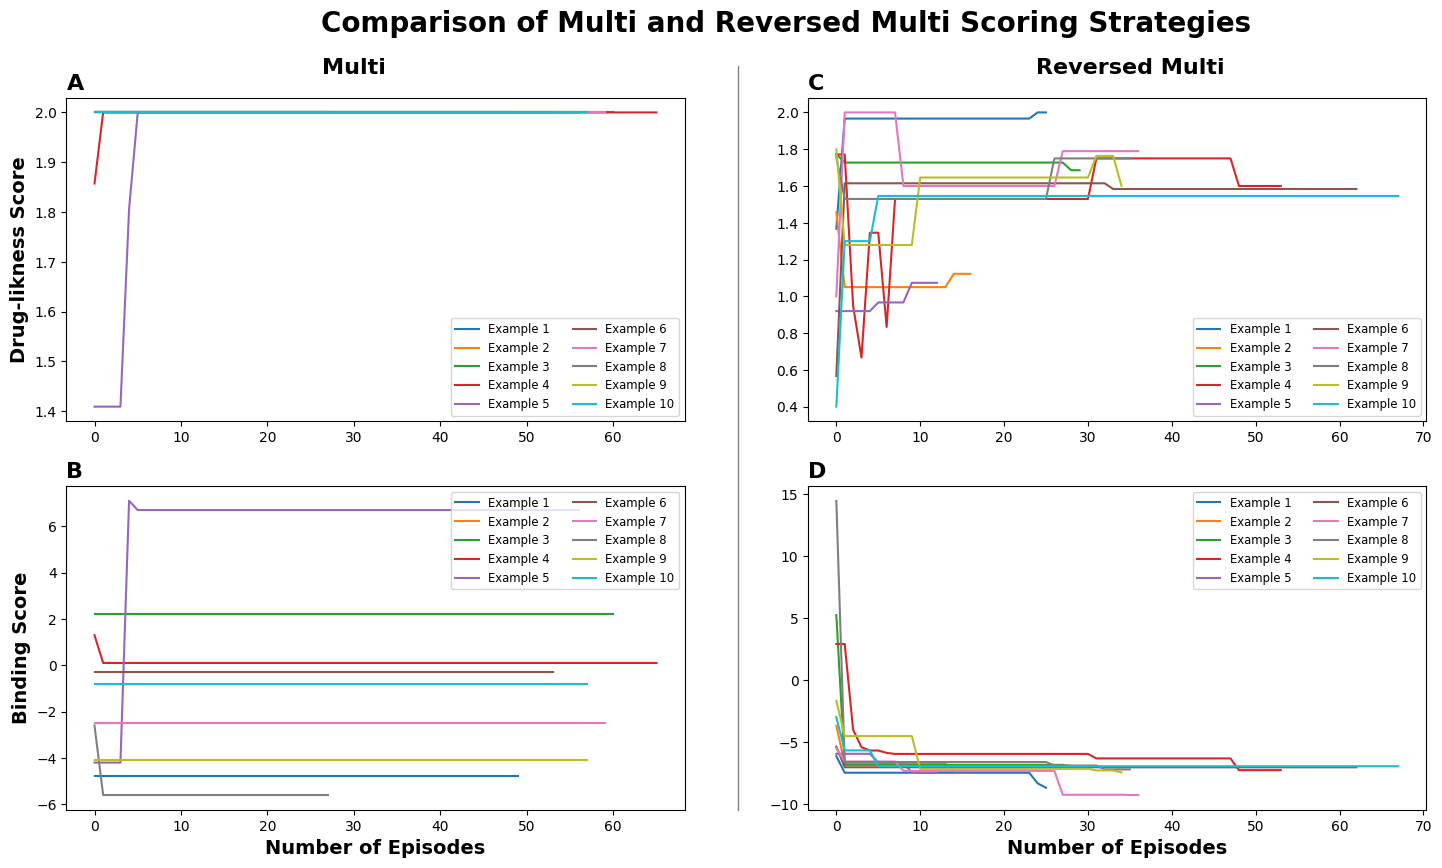

In [39]:
import matplotlib.pyplot as plt
import numpy as np

styles = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--']
colors = plt.cm.tab10(np.linspace(0, 1, 10))



# Create a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(16, 8))

# Plot for lipinski_sc in the top-left subplot (multi_plot)
for i in range(1, 11):
    df = multi_plot[i]
    axs[0, 0].plot(df.index, df['lipinski_sc'], color=colors[i-1], label=f'Example {i}')
axs[0, 0].set_title('A',fontweight='bold',fontsize=16, loc='left')
axs[0, 0].set_xlabel('')
axs[0, 0].set_ylabel('Drug-likness Score', fontweight='bold',fontsize=14 )
axs[0, 0].legend(fontsize='small', ncol=2)
axs[0, 0].grid(False)

# Plot for lipinski_sc in the top-right subplot (rev_plot)
for i in range(1, 11):
    df = rev_plot[i]
    axs[0, 1].plot(df.index, df['lipinski_sc'],color=colors[i-1], label=f'Example {i}')
axs[0, 1].set_title('C',fontweight='bold',fontsize=16, loc='left')
axs[0, 1].set_xlabel('')
axs[0, 1].set_ylabel('')
axs[0, 1].legend(fontsize='small', ncol=2)
axs[0, 1].grid(False)

# Plot for docking_sc in the bottom-left subplot (multi_plot)
for i in range(1, 11):
    df = multi_plot[i]
    axs[1, 0].plot(df.index, df['docking_sc'], color=colors[i-1], label=f'Example {i}')
axs[1, 0].set_title('B',fontweight='bold',fontsize=16, loc='left')
axs[1, 0].set_xlabel('Number of Episodes',fontweight='bold',fontsize=14)
axs[1, 0].set_ylabel('Binding Score',fontweight='bold',fontsize=14)
axs[1, 0].legend(fontsize='small', ncol=2)
axs[1, 0].grid(False)

# Plot for docking_sc in the bottom-right subplot (rev_plot)
for i in range(1, 11):
    df = rev_plot[i]
    axs[1, 1].plot(df.index, df['docking_sc'], color=colors[i-1], label=f'Example {i}')
axs[1, 1].set_title('D',fontweight='bold',fontsize=16, loc='left')
axs[1, 1].set_xlabel('Number of Episodes',fontweight='bold',fontsize=14)
axs[1, 1].set_ylabel('')
axs[1, 1].legend(fontsize='small', ncol=2)
axs[1, 1].grid(False)
plt.suptitle("Comparison of Multi and Reversed Multi Scoring Strategies", fontsize=20, fontweight='bold', y=1.0)
fig.text(0.23, 0.92, 'Multi', ha='center', fontsize=16, fontweight='bold')
fig.text(0.715, 0.92, 'Reversed Multi', ha='center', fontsize=16, fontweight='bold')
plt.subplots_adjust(left=0.05, right=0.9, top=0.89, bottom=0.0, wspace=0.2, hspace=0.2)
from matplotlib.lines import Line2D
line = mlines.Line2D([0.47, 0.47], [0.0, 0.93], transform=plt.gcf().transFigure,
                     color='grey', linewidth=1)  # 0.55 is between plots
fig.add_artist(line)

plt.show()
